In [4]:
import itertools
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

# Load Dataset
data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

p = X.shape[1]

best_rss = []
best_r2 = []
best_features = []

In [5]:
# Best Subset Selection
for k in range(1, p + 1):

    lowest_rss = np.inf
    best_subset = None
    best_subset_r2 = None

    for subset in itertools.combinations(X.columns, k):

        X_subset = sm.add_constant(X[list(subset)])

        model = sm.OLS(y, X_subset).fit()

        rss = np.sum(model.resid ** 2)

        if rss < lowest_rss:
            lowest_rss = rss
            best_subset = subset
            best_subset_r2 = model.rsquared

    best_rss.append(lowest_rss)
    best_r2.append(best_subset_r2)
    best_features.append(best_subset)

    print(f"{k} predictors -> RSS={lowest_rss:.4f}, R²={best_subset_r2:.4f}")


1 predictors -> RSS=14471.3469, R²=0.4734
2 predictors -> RSS=13490.9636, R²=0.5091
3 predictors -> RSS=11425.8851, R²=0.5843
4 predictors -> RSS=11157.4899, R²=0.5940
5 predictors -> RSS=11025.2269, R²=0.5988
6 predictors -> RSS=10854.7700, R²=0.6050
7 predictors -> RSS=10822.3529, R²=0.6062
8 predictors -> RSS=10821.9852, R²=0.6062


In [6]:
print("\nBest model for each size:")
for i in range(p):
    print(f"{i+1} predictors : {best_features[i]}")


Best model for each size:
1 predictors : ('MedInc',)
2 predictors : ('MedInc', 'HouseAge')
3 predictors : ('MedInc', 'Latitude', 'Longitude')
4 predictors : ('MedInc', 'HouseAge', 'Latitude', 'Longitude')
5 predictors : ('MedInc', 'HouseAge', 'AveBedrms', 'Latitude', 'Longitude')
6 predictors : ('MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude')
7 predictors : ('MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude')
8 predictors : ('MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude')


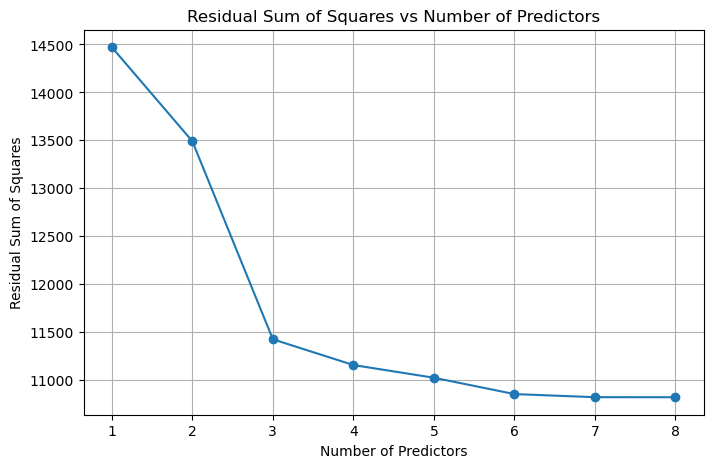

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, p+1),
    best_rss,
    marker='o'
)

plt.xlabel("Number of Predictors")
plt.ylabel("Residual Sum of Squares")
plt.title("Residual Sum of Squares vs Number of Predictors")

plt.grid(True)
plt.show()

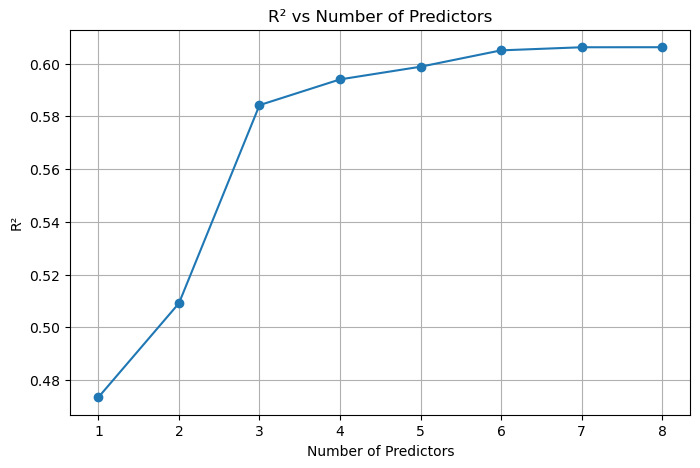

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, p+1),
    best_r2,
    marker='o'
)

plt.xlabel("Number of Predictors")
plt.ylabel("R²")
plt.title("R² vs Number of Predictors")

plt.grid(True)
plt.show()